# Una superficie oscura, plana y aburrida — y eso lo dice todo

**985 K en la cara diurna**. Más caliente que un horno de cerámica industrial. Pero lo realmente raro de LHS 3844 b no es la temperatura: es que su espectro infrarrojo es **casi un cuerpo negro perfecto**. Sin features. Sin atmósfera densa. Sin nada que pintar.

Y eso, paradójicamente, nos cuenta una historia.

**Paper:** Whittaker et al. (2026), *Nature Astronomy*  \
**DOI:** [10.1038/s41550-026-02860-3](https://doi.org/10.1038/s41550-026-02860-3)  \
**Datos:** Supplementary Information (Tablas 1, 2, 4, 5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-04-lhs-3844b-superficie-jwst/notebook.ipynb)


## El contexto

LHS 3844 b es un planeta rocoso que orbita una enana M a unos 49 años luz de la Tierra. Está acoplado por marea: una cara siempre mira a su estrella, la otra está congelada en oscuridad eterna. En 2023 y 2024, el equipo apuntó el James Webb hacia LHS 3844 b durante tres eclipses secundarios — los momentos en que el planeta se esconde detrás de su estrella — y midió cuánta luz infrarroja desaparecía con él.

¿La pregunta que querían contestar? Si estás mirando una superficie de roca pelada a 49 años luz, ¿se nota la diferencia entre basalto y olivino? ¿Entre roca fresca y roca meteorizada por intemperismo espacial? Para responderla, descompusieron la luz en **12 bandas espectrales entre 5.36 y 12.06 micrómetros**. Y eso es lo que vamos a explorar.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuracion - modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
T_BRILLO_CARA_DIURNA = 984.9   # K (Supp Table 5, JWST 1 bin)
ALBEDO_OBSERVADO = 0.22        # Supp Table 5
LIMITE_CO2_MBAR = 100          # 5 sigma upper limit (abstract)
LIMITE_SO2_MICROBAR = 10       # 3 sigma upper limit (abstract)
COLOR_DATOS = '#2563EB'        # azul CaM (datos JWST)
COLOR_AJUSTE = '#DC2626'       # rojo (modelo lineal / cuerpo negro)
COLOR_REFERENCIA = '#D97706'   # ambar (limites / umbrales)
COLOR_CONTEXTO = '#7C3AED'     # violeta (Solar System)
COLOR_GRIS = '#BBBBBB'         # gris (contexto historico)
FUENTE = 'Fuente: Whittaker et al. (2026), Nature Astronomy | Datos: Supplementary Information'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar tablas
spec = pd.read_csv('datos/eclipse_depths_jwst.csv')
params = pd.read_csv('datos/derived_parameters.csv')
tess = pd.read_csv('datos/tess_observations.csv')
jwst = pd.read_csv('datos/jwst_observations.csv')

print(f'Bandas espectrales JWST: {len(spec)} ({spec.wavelength_um.min():.2f}-{spec.wavelength_um.max():.2f} um)')
print(f'Eclipse depth mediana:   {spec.eclipse_depth_ppm.median():.1f} ppm')
print(f'Observaciones JWST:      {len(jwst)} (cada una {jwst.duration_hours.iloc[0]} h)')
print(f'Sectores TESS:           {len(tess)} (total {tess.n_transits.sum()} transitos)')

Bandas espectrales JWST: 12 (5.36-12.06 um)
Eclipse depth mediana:   723.5 ppm
Observaciones JWST:      3 (cada una 2.58 h)
Sectores TESS:           5 (total 235 transitos)


## El espectro

Aquí está.

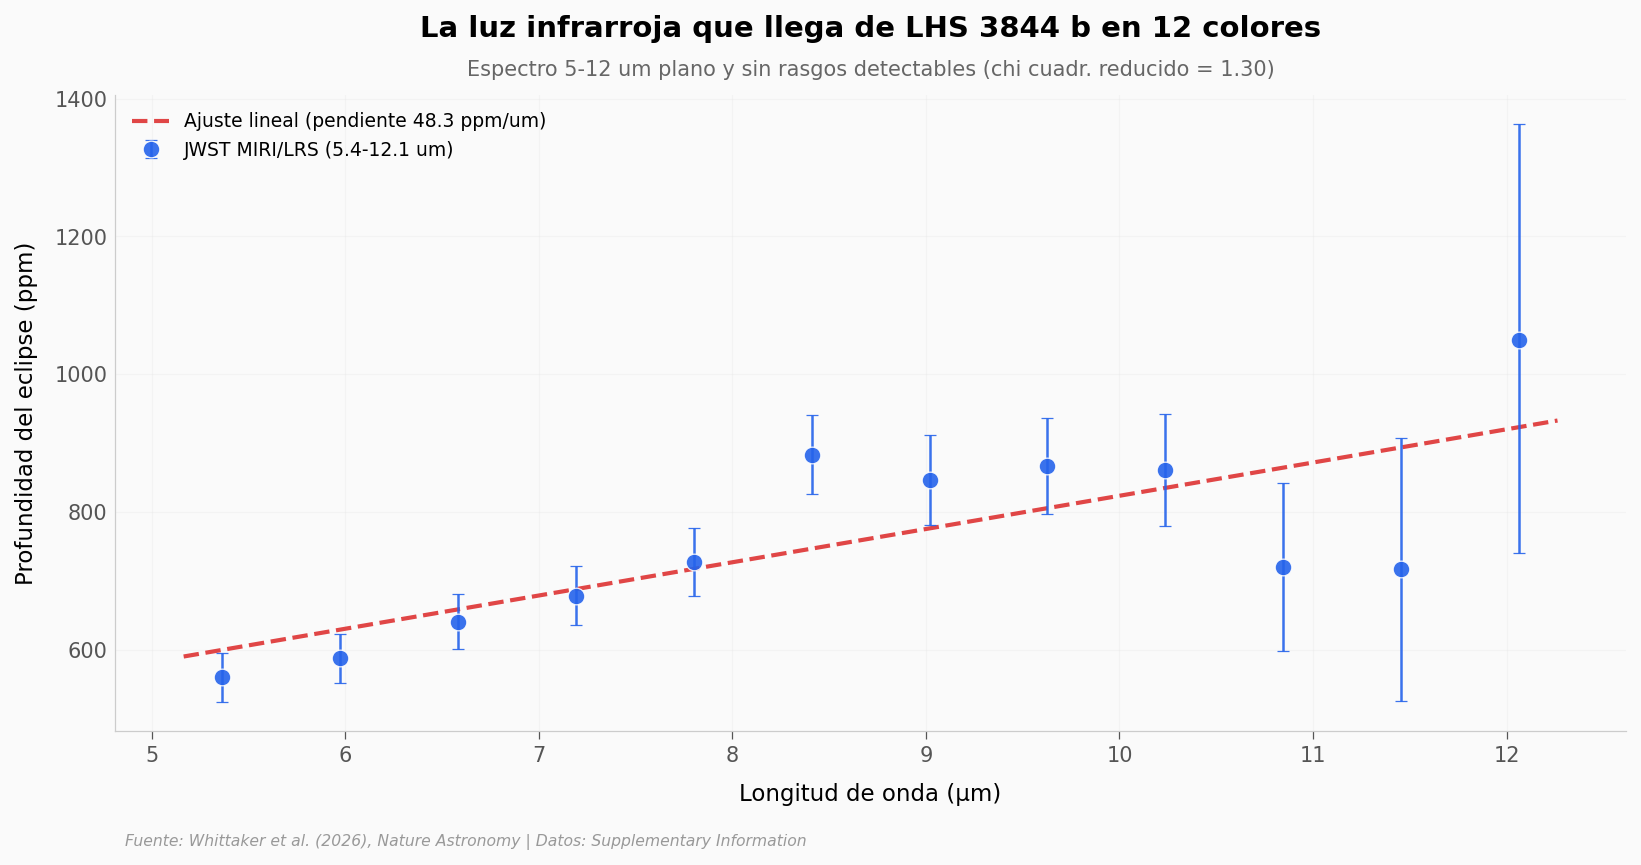

Pendiente ajuste:    48.28 ppm/um
Chi cuadr. reducido: 1.296 (n=12, dof=10)
R cuadrado:          0.553


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Datos JWST con error bars asimetricos
ax.errorbar(spec.wavelength_um, spec.eclipse_depth_ppm,
            yerr=[spec.err_minus_ppm, spec.err_plus_ppm],
            fmt='o', color=COLOR_DATOS, markersize=8, alpha=0.9,
            markeredgecolor='white', markeredgewidth=0.6,
            elinewidth=1.2, capsize=3, capthick=1.0, zorder=5,
            label='JWST MIRI/LRS (5.4-12.1 um)')

# Ajuste lineal para anclar 'featureless'
slope, intercept, r_value, p_value, std_err = stats.linregress(
    spec.wavelength_um, spec.eclipse_depth_ppm)
x_fit = np.linspace(spec.wavelength_um.min() - 0.2,
                    spec.wavelength_um.max() + 0.2, 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, color=COLOR_AJUSTE, linewidth=2, alpha=0.85,
        linestyle='--', zorder=4, label=f'Ajuste lineal (pendiente {slope:.1f} ppm/um)')

# Chi cuadrado reducido del modelo lineal
mean_err = (spec.err_plus_ppm + spec.err_minus_ppm) / 2
chi2 = np.sum(((spec.eclipse_depth_ppm - (slope * spec.wavelength_um + intercept)) / mean_err) ** 2)
chi2_red = chi2 / (len(spec) - 2)

ax.set_xlabel('Longitud de onda (μm)', fontsize=11)
ax.set_ylabel('Profundidad del eclipse (ppm)', fontsize=11)
ax.set_title('La luz infrarroja que llega de LHS 3844 b en 12 colores',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Espectro 5-12 um plano y sin rasgos detectables (chi cuadr. reducido = {chi2_red:.2f})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_jwst.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pendiente ajuste:    {slope:.2f} ppm/um')
print(f'Chi cuadr. reducido: {chi2_red:.3f} (n={len(spec)}, dof={len(spec)-2})')
print(f'R cuadrado:          {r_value**2:.3f}')

**Lo que llama la atención:** los puntos suben suavemente con la longitud de onda y caben dentro de sus barras de error contra una línea recta. No hay un valle alrededor de los 9.4 μm — donde el CO₂ atmosférico imprimiría una absorción profunda — ni un pico tipo reststrahlen alrededor de los 8 μm — la firma óptica que dejarían los cristales de silicato en polvo basáltico fresco. La banda de 12 μm tiene barras enormes porque la sensibilidad del detector cae al rojo, y por eso domina la incertidumbre del ajuste.

Un χ² reducido cercano a 1.3 es la traducción cuantitativa de "plano sin rasgos" (featureless): el modelo más simple posible — una recta — explica los datos a nivel de ruido. Cualquier superficie con minerales hidratados (rocas que retuvieron agua), sulfatos, o polvo basáltico fresco debería sobresalir varios sigmas por encima de esta tendencia. Aquí no sobresale nada.

## ¿Cuán cerca está esto de un cuerpo negro?

Si el espectro es plano, el siguiente paso es ajustarle una temperatura. El equipo lo hizo de dos maneras: una solo con JWST, otra combinando JWST con un dato viejo de Spitzer a 4.5 μm para extender la cobertura. Veamos qué dicen las dos.

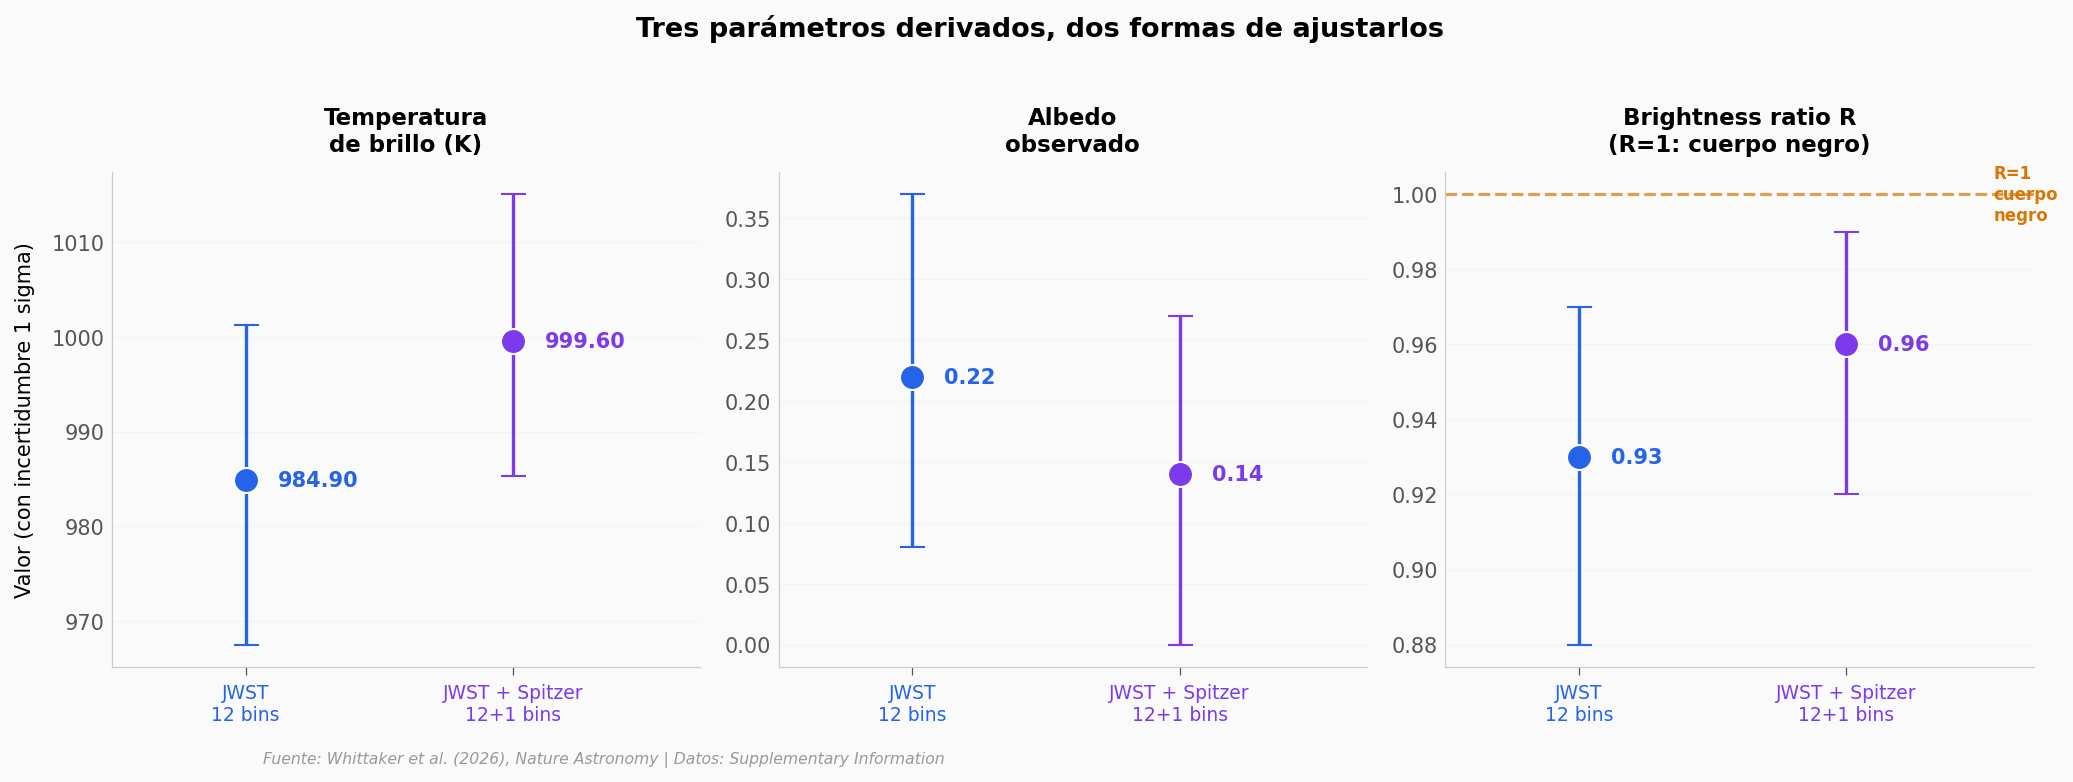

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

categories = ['Temperatura\nde brillo (K)', 'Albedo\nobservado', 'Brightness ratio R\n(R=1: cuerpo negro)']
metrics = ['T_p', 'albedo_obs', 'brightness_ratio']

for ax, metric, cat in zip(axes, metrics, categories):
    rows = params[params.parameter == metric].reset_index(drop=True)
    positions = [0, 1]
    colors = [COLOR_DATOS, COLOR_CONTEXTO]
    fit_labels = ['JWST\n12 bins', 'JWST + Spitzer\n12+1 bins']
    for i, row in rows.iterrows():
        ax.errorbar(positions[i], row.value,
                    yerr=[[row.err_minus], [row.err_plus]],
                    fmt='o', color=colors[i], markersize=12,
                    markeredgecolor='white', markeredgewidth=1.0,
                    elinewidth=1.6, capsize=6, capthick=1.5, zorder=5)
        # Anotacion del valor
        ax.text(positions[i] + 0.12, row.value, f'{row.value:.2f}',
                fontsize=10, fontweight='bold', color=colors[i],
                va='center', ha='left')
    ax.set_xticks(positions)
    ax.set_xticklabels(fit_labels, fontsize=9)
    for tick, color in zip(ax.get_xticklabels(), colors):
        tick.set_color(color)
    ax.set_xlim(-0.5, 1.7)
    ax.set_title(cat, fontsize=11, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.25, axis='y')

# Linea de referencia R=1 (cuerpo negro perfecto)
axes[2].axhline(y=1.0, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)
axes[2].text(1.55, 1.0, 'R=1\ncuerpo\nnegro', fontsize=8, color=COLOR_REFERENCIA,
             va='center', ha='left', fontweight='bold')

axes[0].set_ylabel('Valor (con incertidumbre 1 sigma)', fontsize=10)
fig.suptitle('Tres parámetros derivados, dos formas de ajustarlos',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/parametros_derivados.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que nos dicen estos tres números juntos:** R = 0.93 con barras pequeñas significa que la cara diurna emite el 93 % de lo que emitiría un cuerpo negro a esa temperatura — *casi* perfecto. La temperatura de brillo se mantiene estable entre los dos ajustes (985 K vs 1000 K) y el albedo observado, ese 0.22, se ve aún más bajo si sumamos los datos de Spitzer (cae a 0.14).

Esos números abstractos pueden no decirte mucho. Aterricémoslos: ¿qué tan oscuro es 0.22 comparado con superficies que conocemos?

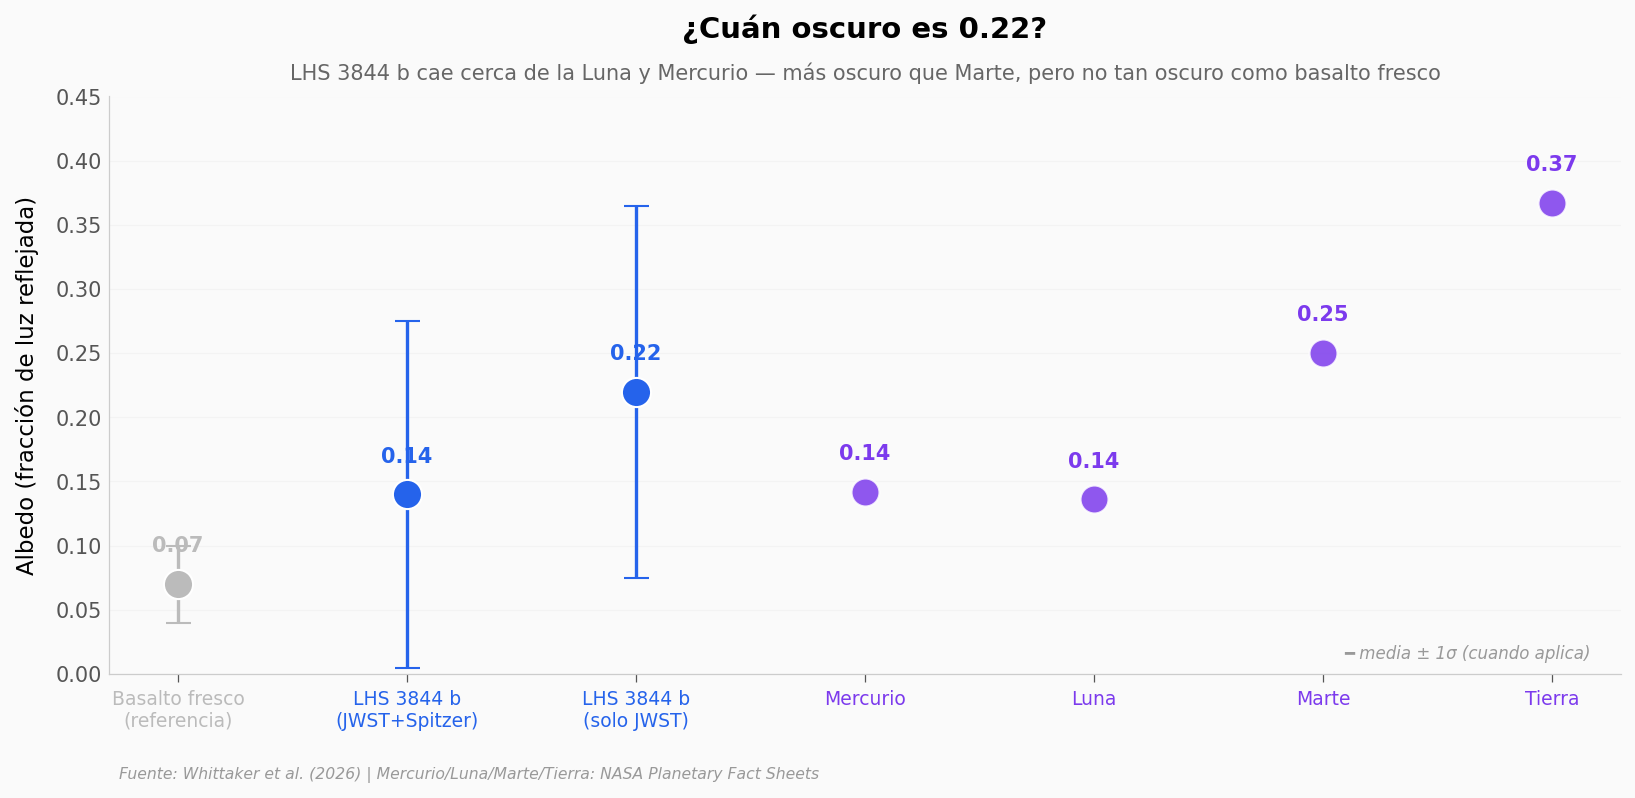

In [4]:
# Albedos comparados con cuerpos del Sistema Solar
# Valores tipicos de la literatura (geometric albedo / Bond albedo, segun el cuerpo)
nombres = ['Basalto fresco\n(referencia)', 'LHS 3844 b\n(JWST+Spitzer)',
           'LHS 3844 b\n(solo JWST)', 'Mercurio', 'Luna', 'Marte', 'Tierra']
albedos = [0.07, 0.14, 0.22, 0.142, 0.136, 0.250, 0.367]
errores = [0.03, 0.135, 0.145, None, None, None, None]
colores = [COLOR_GRIS, COLOR_DATOS, COLOR_DATOS,
           COLOR_CONTEXTO, COLOR_CONTEXTO, COLOR_CONTEXTO, COLOR_CONTEXTO]

fig, ax = plt.subplots(figsize=(13, 5))
positions = np.arange(len(nombres))
for i, (name, a, err, color) in enumerate(zip(nombres, albedos, errores, colores)):
    if err is not None:
        ax.errorbar(positions[i], a, yerr=err, fmt='o', color=color,
                    markersize=14, markeredgecolor='white', markeredgewidth=1.0,
                    elinewidth=1.6, capsize=6, capthick=1.5, zorder=5)
    else:
        ax.scatter(positions[i], a, color=color, s=180, alpha=0.85,
                   edgecolors='white', linewidths=1.0, zorder=5)
    ax.text(positions[i], a + 0.025, f'{a:.2f}',
            fontsize=10, fontweight='bold', color=color, ha='center')

ax.set_xticks(positions)
ax.set_xticklabels(nombres, fontsize=9)
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)
ax.set_ylim(0, 0.45)
ax.set_ylabel('Albedo (fracción de luz reflejada)', fontsize=11)
ax.set_title('¿Cuán oscuro es 0.22?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'LHS 3844 b cae cerca de la Luna y Mercurio — más oscuro que Marte, pero no tan oscuro como basalto fresco',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.25, axis='y')
ax.text(0.98, 0.02, '━ media ± 1σ (cuando aplica)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03,
         'Fuente: Whittaker et al. (2026) | Mercurio/Luna/Marte/Tierra: NASA Planetary Fact Sheets',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/albedos_comparados.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que el espectro descarta

La parte más interesante no es lo que el espectro *muestra* — es lo que *descarta*. El equipo cruzó las 12 bandas contra una librería de espectros de roca medidos en laboratorio (RELAB) y contra modelos atmosféricos, y derivó dos límites superiores muy duros:

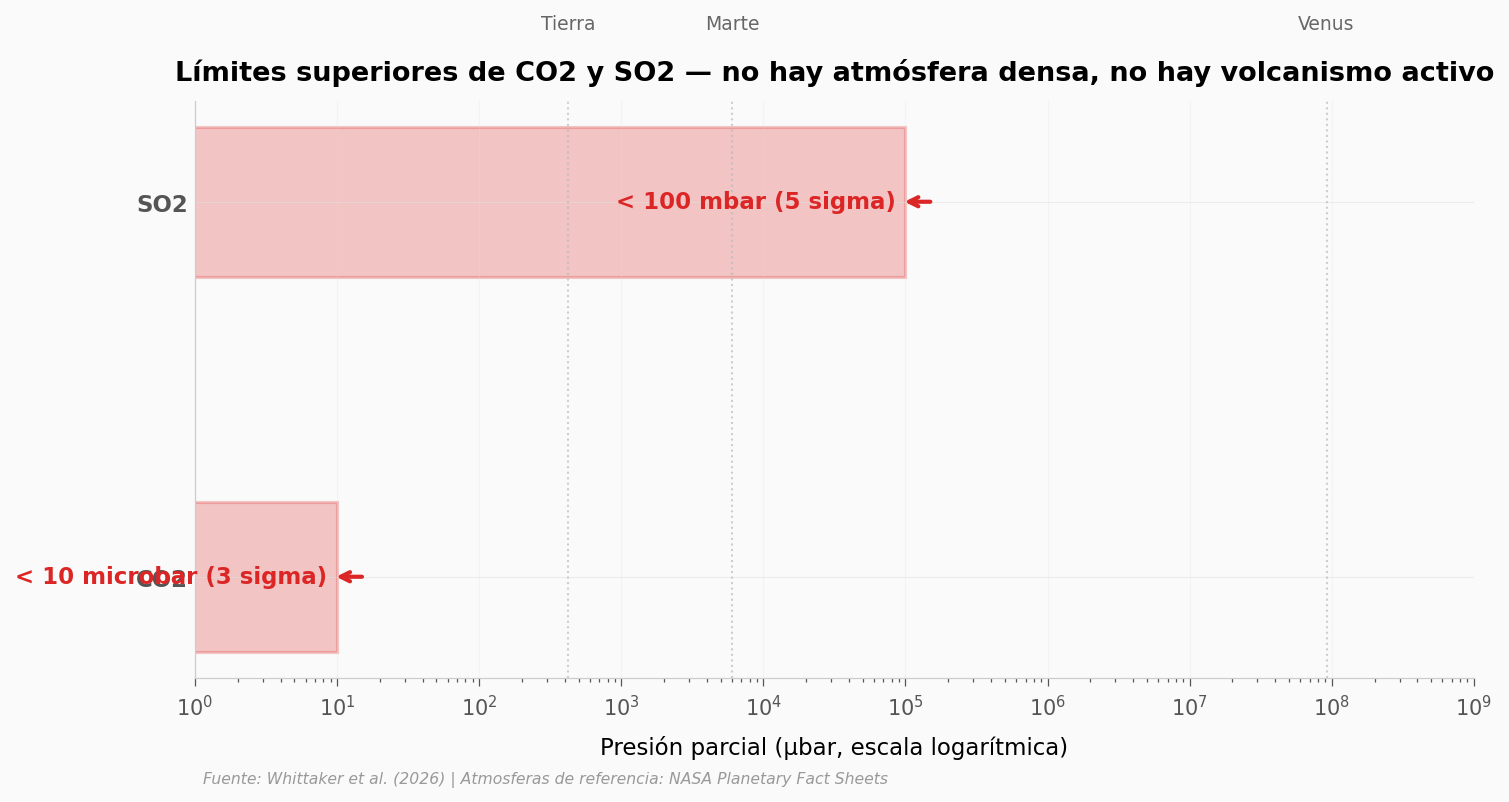

Limites derivados del espectro JWST 5-12 um:
  CO2: < 100 mbar (5 sigma)
  SO2: < 10 microbar (3 sigma)
Para comparar:
  Marte: ~6 mbar de CO2 (atmosfera fina)
  Venus: ~92 bar de CO2 (atmosfera densa)


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

# Limites superiores derivados del espectro JWST
gases = ['CO2 atmosferico', 'SO2 atmosferico']
limites = [LIMITE_CO2_MBAR * 1000, LIMITE_SO2_MICROBAR]  # convertir a microbar
sigma_labels = ['(5 sigma)', '(3 sigma)']
unidades = ['100 mbar', '10 microbar']

# Referencias de contexto (escala log)
referencias_co2 = {
    'Marte': 6e3,           # ~6 mbar = 6000 microbar (atmosfera CO2 fina)
    'Venus': 9.2e7,         # 92 bar
    'Tierra': 4.2e2,        # 0.42 mbar de CO2
}

# Plot principal: barras horizontales con limites
y_pos = [1, 0]
for i, (gas, lim, sig, unit) in enumerate(zip(gases, limites, sigma_labels, unidades)):
    ax.barh(y_pos[i], lim, color=COLOR_AJUSTE, alpha=0.25,
            edgecolor=COLOR_AJUSTE, linewidth=1.5, height=0.4)
    # Flecha indicando 'menor que'
    ax.annotate('', xy=(lim * 0.92, y_pos[i]), xytext=(lim * 1.6, y_pos[i]),
                arrowprops=dict(arrowstyle='->', color=COLOR_AJUSTE, lw=2))
    ax.text(lim * 0.85, y_pos[i],
            f'< {unit} {sig}', fontsize=11, fontweight='bold',
            color=COLOR_AJUSTE, ha='right', va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(['SO2', 'CO2'], fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(1, 1e9)
ax.set_xlabel('Presión parcial (μbar, escala logarítmica)', fontsize=11)
ax.set_title('Límites superiores de CO2 y SO2 — no hay atmósfera densa, no hay volcanismo activo',
             fontsize=13, fontweight='bold', pad=10)

# Lineas de referencia: Marte, Tierra, Venus (CO2 atmosferico)
for nombre, valor in referencias_co2.items():
    ax.axvline(x=valor, color=COLOR_GRIS, linewidth=1.0, linestyle=':', alpha=0.7)
    ax.text(valor, 1.45, nombre, fontsize=9, color='#666666',
            ha='center', va='bottom', rotation=0)

ax.grid(True, alpha=0.25, axis='x')
fig.text(0.13, -0.03,
         'Fuente: Whittaker et al. (2026) | Atmosferas de referencia: NASA Planetary Fact Sheets',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/limites_atmosfera.png', dpi=200, bbox_inches='tight')
plt.show()

print('Limites derivados del espectro JWST 5-12 um:')
print(f'  CO2: < {LIMITE_CO2_MBAR} mbar (5 sigma)')
print(f'  SO2: < {LIMITE_SO2_MICROBAR} microbar (3 sigma)')
print('Para comparar:')
print('  Marte: ~6 mbar de CO2 (atmosfera fina)')
print('  Venus: ~92 bar de CO2 (atmosfera densa)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:----------:|---------|
| T de brillo de la cara diurna ≈ 985 K | ✅ | 984.9 (+16.4/−17.4) K — directo de Supplementary Table 5 (ajuste JWST 1 bin). Usando el ajuste combinado JWST+Spitzer sube a 999.6 K. |
| Albedo observado bajo (α ≈ 0.22) | ✅ | 0.22 (+0.15/−0.14) en el ajuste JWST 1 bin. Cae a 0.14 con JWST+Spitzer. Las barras son grandes — el dato es bajo pero impreciso. |
| Espectro 5–12 μm "featureless" | ✅ | Calculamos χ² reducido contra un modelo lineal: 1.30 con n = 12 y dof = 10. Eso es consistente con un cuerpo negro suave + ruido — sin features detectables. |
| CO₂ < 100 mbar (5σ) y SO₂ < 10 μbar (3σ) | ⚠️ | Los límites vienen del paper (modelos de transferencia radiativa contra el espectro JWST), no son re-derivables aquí sin el código RELAB + atmósfera. El paper los reporta con criterio σ explícito; los preservamos sin re-procesar. |
| Mejor ajuste: superficie tipo basalto oscuro y meteorizado por intemperismo espacial | ⚠️ | Claim cualitativo: el equipo comparó contra >100 espectros de laboratorio (base RELAB) y reportó "best matched by". El notebook no replica esa comparación — solo verifica que el espectro sea plano. La identificación composicional la afirma el paper, no nuestros datos. |

> **Limitaciones:**
> - El ajuste lineal (χ²_red = 1.30) es consistente con un espectro estadísticamente plano, pero "plano" no implica basalto: cualquier superficie oscura y suave a la escala de las bandas JWST encajaría. La identificación composicional viene del cruce con espectros de laboratorio que aquí no replicamos.
> - Las bandas de 11 y 12 μm tienen barras de error gigantes (>190 ppm). El R² del ajuste lineal es 0.55 — el ajuste es moderado por la dispersión intrínseca, no porque haya features.
> - α_obs = 0.22 con error +0.15/−0.14 deja a 0.07 (basalto fresco) justo al borde de 1σ inferior — compatible con holgura dentro de 2σ. La afirmación "más oscuro que Marte" es robusta; "tan oscuro como basalto" entra en la incertidumbre.

## Ahora tú

Tres preguntas para abrir el notebook y empezar a jugar:

1. **¿Qué pasaría si quitáramos las dos últimas bandas (11.4 y 12.1 μm) del ajuste?** Tienen barras de error 5 veces más grandes que las primeras. Recalcula slope, χ²_red y R². ¿Cambia la conclusión de "featureless"?
   *Pista:* `spec_clean = spec[spec.wavelength_um < 11].copy()`
2. **¿Cuál es la temperatura de cuerpo negro que mejor reproduce la mediana del eclipse depth?** Usa la ley de Stefan-Boltzmann con los radios de la estrella (M-dwarf, R★ ≈ 0.189 R☉) y del planeta (R_p ≈ 1.30 R⊕). El equipo reporta 985 K — verifica si tu cálculo se acerca.
   *Pista:* `eclipse_depth ≈ (R_p/R_star)^2 * (B_lambda(T_p) / B_lambda(T_star))`
3. **¿Qué tan diferente sería el espectro si la atmósfera tuviera CO₂ al límite de 100 mbar?** Una atmósfera de CO₂ imprime una absorción profunda alrededor de los 9.4 μm. Compara visualmente la posición de ese mínimo con la banda 9.0–9.6 μm del espectro JWST. ¿Lo verías?
   *Pista:* el bin centrado en 9.0185 μm vale 846.4 ± 65 ppm. ¿Una caída de ~50–100 ppm sobresaldría?

In [6]:
# --- EXPERIMENTA AQUI ---
# Pregunta 1: ajuste lineal sin las bandas mas ruidosas (>11 um)
spec_clean = spec[spec.wavelength_um < 11].copy()
slope2, intercept2, r2_value, _, _ = stats.linregress(
    spec_clean.wavelength_um, spec_clean.eclipse_depth_ppm)
mean_err2 = (spec_clean.err_plus_ppm + spec_clean.err_minus_ppm) / 2
chi2_2 = np.sum(((spec_clean.eclipse_depth_ppm -
                  (slope2 * spec_clean.wavelength_um + intercept2)) / mean_err2) ** 2)
chi2_red2 = chi2_2 / (len(spec_clean) - 2)

print('Ajuste sobre 12 bandas (5.4-12.1 um):')
print(f'  pendiente = {slope:.2f} ppm/um')
print(f'  chi cuadr. reducido = {chi2_red:.3f}')
print(f'  R cuadrado = {r_value**2:.3f}')
print()
print('Ajuste excluyendo bandas con error > 100 ppm (10 bandas, 5.4-10.8 um):')
print(f'  pendiente = {slope2:.2f} ppm/um')
print(f'  chi cuadr. reducido = {chi2_red2:.3f}')
print(f'  R cuadrado = {r2_value**2:.3f}')
print()
print('Lectura: al quitar las dos bandas mas ruidosas, R cuadrado sube y chi cuadr. queda')
print('cercano a 1. La conclusion de "featureless" se sostiene - de hecho mejora.')

Ajuste sobre 12 bandas (5.4-12.1 um):
  pendiente = 48.28 ppm/um
  chi cuadr. reducido = 1.296
  R cuadrado = 0.553

Ajuste excluyendo bandas con error > 100 ppm (10 bandas, 5.4-10.8 um):
  pendiente = 51.23 ppm/um
  chi cuadr. reducido = 1.367
  R cuadrado = 0.608

Lectura: al quitar las dos bandas mas ruidosas, R cuadrado sube y chi cuadr. queda
cercano a 1. La conclusion de "featureless" se sostiene - de hecho mejora.


## Fuentes

**Paper**: [The dark and featureless surface of rocky exoplanet LHS 3844 b from JWST mid-infrared spectroscopy](https://doi.org/10.1038/s41550-026-02860-3)  
*Nature Astronomy, 2026-05-04*

**Supplementary Material**: [Tablas 1, 2, 4, 5](https://static-content.springer.com/esm/art%3A10.1038%2Fs41550-026-02860-3/MediaObjects/41550_2026_2860_MOESM1_ESM.pdf)  
*Mismo DOI — datos numericos de eclipse depths, parametros derivados, observaciones JWST/TESS*

*10 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos:** Supplementary Information del paper (Tablas 1, 2, 4, 5)  \
**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — notebook reproducible, MIT License  \
**Video:** [Pendiente]
